# Linear Regression From Scratch
Author-$ Abhimanyu Saklani$

## Introduction

Linear Regression is one of the fundamental supervised learning algorithms used for predicting a continuous target variable based on one or more input features.

The goal of Linear Regression is to find the best relationship between input variables (**features**) and the output variable (**target**) by fitting a linear equation.

The general form of a linear regression model is:

 $ \  [
\hat{y} = Xw + b $
\] 

Where:

- $\hat{y}$ : Predicted target value
- $X$ : Input feature matrix
- $w$ : Model weights (coefficients)
- $b$ : Bias/intercept term


## Objective

The model learns weights and bias by minimizing the difference between actual and predicted values.

The most common loss function used for regression is **Mean Squared Error (MSE)**:

\[ $
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2 $
\]

The objective is to find parameters that minimize this error:

\[ $
\min ||y-\hat{y}||^2 $
\]


## Implementations

In this notebook, Linear Regression is implemented from scratch using different optimization approaches:

1. **Ordinary Least Squares (OLS)**
   - Closed-form solution using the Normal Equation.
   - Directly computes optimal weights.

2. **Batch Gradient Descent**
   - Updates parameters using the gradient calculated from the entire dataset.

3. **Stochastic Gradient Descent (SGD)**
   - Updates parameters using one training sample at a time.

4. **Mini-Batch Gradient Descent**
   - Updates parameters using small batches of training samples.
   - Provides a balance between Batch GD stability and SGD speed.


## Dataset

The implementations are evaluated on the **California Housing Dataset**.

Dataset contains:
- Multiple housing-related features
- Continuous target variable representing median house value


## Evaluation Metrics

Models are compared using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score


The results are compared against Scikit-learn's `LinearRegression` implementation.

## 1. Import Libraries

In [10]:
import numpy as np
import pandas as pd

## 2. Add Evaluation Metrices

### Regression models are evaluated by comparing the predicted values ($\hat{y}$) with the actual target values ($y$).  
The following metrics are used to measure prediction error and model performance.
---
###  Validation helper function

In [20]:
def _validate_inputs(y_true : np.ndarray, y_pred :np.ndarray):
    ''' Validates Input by Comparing Shapes '''
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.shape != y_pred.shape:
        raise ValueError(
            'y_true and y_pred must have same shape'
        )
    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        raise ValueError(
                'Inputs must not contain NaN values'
                )
    return y_true, y_pred

## i. Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between actual and predicted values.

It gives the average magnitude of prediction errors and treats all errors equally.

### Formula

$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}| $

### Range 
\[ $
0 \leq MAE < \infty $
\]


In [22]:
def mean_absolute_error(y_true : np.ndarray, y_pred :np.ndarray) -> float:
    ''' Returns Mean Absolute Error = (1/n) Σ (|y_true(i) - y_pred(i)|)'''
    y_true, y_pred = _validate_inputs(y_true, y_pred)
    return np.mean(np.abs(y_true - y_pred)).item()

# ii. Mean Squared Error (MSE)

Mean Squared Error (MSE) measures the average squared difference between the actual target values and the predicted values.

It calculates the error by subtracting predicted values from actual values, squaring the differences, and then taking their average.

Since the errors are squared, larger prediction errors are penalized more heavily compared to smaller errors.

## Formula

$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y_i})^2 $


## Range

\[$
0 \leq MSE < \infty $
\]

In [24]:
def mean_squared_error(y_true : np.ndarray, y_pred :np.ndarray) -> float:
    ''' Returns Mean Squared Error = (1/n) Σ (y_true(i) - y_pred(i))^2'''
    y_true, y_pred = _validate_inputs(y_true, y_pred)
    return np.mean(np.square(y_true - y_pred)).item()

# iii. Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) measures the square root of the average squared difference between the actual target values and the predicted values.

It is derived from Mean Squared Error (MSE) by taking the square root, which converts the error back into the same unit as the target variable.

Since it is based on squared errors, larger prediction errors are penalized more heavily.

## Formula

$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y_i})^2
}$


## Range
\[$
0 \leq RMSE < \infty$
\]

In [26]:
def root_mean_squared_error(y_true : np.ndarray, y_pred :np.ndarray) -> float:
    ''' Returns Root Mean Squared Error = √((1/n) Σ (y_true(i) - y_pred(i))^2)'''
    return np.sqrt(mean_squared_error(y_true, y_pred)).item()

# iv. Mean Absolute Percentage Error (MAPE)

Mean Absolute Percentage Error (MAPE) measures the average percentage difference between the actual target values and the predicted values.

It calculates the absolute error as a percentage of the actual value, making it easier to interpret the prediction error relative to the scale of the target variable.

MAPE is useful when understanding the relative size of errors is more important than their absolute magnitude.

## Formula
$
MAPE =
\frac{1}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\hat{y_i}}{y_i}
\right|
\times 100
$

## Range
$
0 \leq MAPE < \infty
$

In [28]:
def mean_absolute_percentage_error(y_true : np.ndarray, y_pred :np.ndarray) -> float:
    ''' Returns Mean Absolute Percentage Error  = (1/n) Σ (|y_true(i) - y_pred(i)|/y_true) X 100'''
    y_true, y_pred = _validate_inputs(y_true, y_pred)
    return np.mean(np.abs(y_true - y_pred)/np.abs(y_true)).item() * 100

# v. R² Score (Coefficient of Determination)

R² Score measures how well the regression model explains the variation in the target variable.

It compares the prediction error of the model with the total variation present in the actual values.

A higher R² value indicates that the model explains more variance in the target variable.

## Formula
$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i-\hat{y_i})^2
}
{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$
## Range
$
-\infty < R^2 \leq 1
$

- **1** → Perfect prediction
- **0** → Model performs the same as predicting the mean value
- **< 0** → Model performs worse than predicting the mean value
- Higher values indicate better model performance

In [30]:
def r2_score(y_true : np.ndarray, y_pred :np.ndarray) -> float:
    ''' Returns R2 Score = 1- (Residual Sum of Squares/ Total Sum of Squares)'''
    y_true, y_pred = _validate_inputs(y_true, y_pred)
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    if ss_tot == 0:
        return np.nan
    r2 = 1 - (ss_res/ss_tot)
    return r2.item()

In [32]:
def score(y_true : np.ndarray, y_pred :np.ndarray) -> dict:
    ''' Returns dictionary of Evaluation Metrics of regression ie MSE, MAE, RMSE, R2, MAPE'''
    metrics = {
                    'MAE'   : mean_absolute_error(y_true, y_pred),
                    'MSE'   : mean_squared_error(y_true, y_pred),
                    'RMSE'  : root_mean_squared_error(y_true, y_pred),
                    'MAPE'  : mean_absolute_percentage_error(y_true, y_pred),
                    'R2'    : r2_score(y_true, y_pred)
                }
    return metrics

## 3. Add Exception Handling Classes

In [36]:
class ModelNotTrainedError(Exception):
    '''
    Raised when predict() is called before fit()
    '''
    pass

In [34]:
class InvalidShapeError(Exception):
    '''
    Raised when input shape is incompatible
    '''
    pass

In [38]:
class InvalidDataError(Exception):
    '''
    Raised when input contains invalid values
    '''
    pass

# 4. Base Regression Class

The `BaseRegression` class provides a common interface and shared functionality for all regression models implemented in this project.

It acts as a parent class for different regression algorithms such as:

- Ordinary Least Squares (OLS)
- Batch Gradient Descent
- Stochastic Gradient Descent (SGD)
- Mini-Batch Gradient Descent

The purpose of this class is to avoid code duplication and ensure that all regression models follow the same structure.

---

In [40]:
class BaseRegression:
    def __init__(self):
        self.weights = None
        self.bias = None
        
    def _check_is_fitted(self):
        if self.weights is None or self.bias is None:
            raise ModelNotTrainedError(
                'Model is not trained. Call fit() first'
            )
        
    def predict(self, X : np.ndarray)-> np.ndarray:
        '''
        Predict target values using the trained linear regression model
        Parameters
        X      : np.ndarray - Input feature matrix of shape (n_samples, n_features).
        Returns: np.ndarray - Predicted target values.
        '''
        self._check_is_fitted()
        return X @ self.weights + self.bias

    def evaluate(self, y_true : np.ndarray, y_pred : np.ndarray) -> dict:
        '''
        Evaluate Regression model using MSE, MAE, RMSE, MAPE, R2
        '''
        return score(y_true, y_pred)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        '''
        Return the coefficient of determination (R²)
        '''
        return r2_score(y, self.predict(X))

# 4.1 Linear Regression using Ordinary Least Squares (OLS)

Ordinary Least Squares (OLS) is a closed-form approach for solving Linear Regression.

It finds the optimal weights and bias by minimizing the sum of squared differences between actual and predicted values.

The objective is:

$ min ||y-\hat{y}||^2 $

where:

$ \hat{y}=Xw+b $

The optimal weights are calculated using the Normal Equation:

$ w=(X^TX)^{-1}X^Ty $

In this implementation, the pseudo-inverse is used instead of the direct inverse to handle singular or non-invertible matrices.

$
w=(X^TX)^+X^Ty $

---

## Algorithm Steps

1. Add a bias column of ones to the input feature matrix.
2. Compute the optimal coefficients using the Normal Equation.
3. Separate the calculated parameters into:
   - Weights ($w$)
   - Bias ($b$)
4. Use the learned parameters for prediction.

---

## Advantages

- Provides an exact solution without iterative optimization.
- No learning rate or number of iterations required.
- Fast for small and medium-sized datasets.

---

## Limitations

- Computationally expensive for large datasets.
- Requires matrix inversion operations.
- Not suitable for very high-dimensional data.

---

In [42]:
class LinearRegressionOLS(BaseRegression):
    '''
    Implements Linear Regression by using Oridnary Least Squares
                y_hat = X.w + b 
    Where :
        X - Input Features
        y - continous target variable
        w - weights/ coefficents
        b - bias/intercept
    Objective: min ||y - y_hat||^2
    Using Normal Equation: (X.T @ X) w = X.T @ y
    '''
    def __init__(self):
        super().__init__()

    def fit(self, X, y) :
        X = np.asarray(X)
        y = np.asarray(y)
        n, p = X.shape

        self.n_features_in_ = p
        #Add bias vector to the features
        X_b = np.column_stack([np.ones(n),X])
        #Compute w using Normal Equation
        w = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

        self.bias = w[0]
        self.weights = w[1:]

        return self

# 4. 2 Linear Regression using Batch Gradient Descent

Batch Gradient Descent is an iterative optimization algorithm used to minimize the Mean Squared Error (MSE) loss function.

Instead of directly calculating the optimal solution, it updates the model parameters step-by-step using the gradients calculated from the complete training dataset.

The prediction equation is:

$
\hat{y}=Xw+b $

The objective function is:

$
MSE=\frac{1}{n}\sum(y_i-\hat{y_i})^2 $

---

## Gradient Update

The gradients of weights and bias are calculated as:

$
dw=-\frac{2}{n}X^T(y-\hat{y}) $


$
db=-\frac{2}{n}\sum(y-\hat{y})
$

Parameters are updated using:

$
w=w-\alpha dw$

$
b=b-\alpha db
$

where:

- $\alpha$ = Learning rate

---

## Algorithm Steps

1. Initialize weights and bias to zero.
2. Calculate predictions using current parameters.
3. Compute prediction error.
4. Calculate gradients using all training samples.
5. Update weights and bias.
6. Repeat for the specified number of iterations.

---

## Advantages

- Works well for large datasets.
- Does not require matrix inversion.
- Can handle high-dimensional features.

---

## Limitations

- Requires selecting a suitable learning rate.
- Sensitive to feature scaling.
- May converge slowly.

In [48]:
class LinearRegressionBatchGD(BaseRegression):
    '''
    Implements Batch Gradient Descent Linear Regression
                y_hat = X.w + b
    Where
        X     - Input Features
        y_hat - continous target variable
        w     - weights/ coefficents
        b     - bias/intercept
    '''
    def __init__(self, lr = 0.01, max_iter = 10000, verbose = None):
        if lr <= 0:
            raise ValueError("learning_rate must be greater than 0")
        if max_iter <= 0:
            raise ValueError("max_iter must be greater than 0")
        self.learning_rate = lr
        self.max_iter = max_iter
        self.verbose = verbose
        self.loss_history_ = []
        super().__init__()

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n, p = X.shape

        #Initialize parameters
        self.n_features_in_ = X.shape[1]
        self.weights = np.zeros(p)
        self.bias = 0.0

        for itr in range(self.max_iter):

            #Forward pass
            y_hat = X @ self.weights + self.bias
            #prediction error
            error = y - y_hat
            
            # Compute gradients of the MSE loss
            dw = -(2/n)* (X.T @ error)
            db = -(2/n)* np.sum(error)

            #Update parameters using gradient descent
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = np.mean(error ** 2)
            self.loss_history_.append(loss)

            if self.verbose and itr % self.verbose == 0:
                print(f"Iteration {itr}, Loss: {loss:.6f}")

        return self

# 4.3 Linear Regression using Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent is a variation of Gradient Descent where model parameters are updated after processing each individual training sample.

Instead of calculating gradients using the complete dataset, SGD performs frequent updates using one sample at a time.

The prediction equation is:
$
\hat{y}=Xw+b
$

---

## Gradient Update

For a single sample:

$
dw=-2x_i(y_i-\hat{y_i})
$

$
db=-2(y_i-\hat{y_i})
$

Parameters are updated as:

$
w=w-\alpha dw
$

$
b=b-\alpha db
$

---

## Algorithm Steps

1. Initialize weights and bias.
2. Shuffle training samples (optional).
3. Select one sample at a time.
4. Calculate prediction error.
5. Update weights and bias.
6. Repeat for multiple epochs.

---

## Advantages

- Faster updates compared to Batch Gradient Descent.
- Works well for very large datasets.
- Can escape local minima due to noisy updates.

---

## Limitations

- Updates have high variance.
- Loss may fluctuate during training.
- Requires careful learning rate selection.


In [44]:
class LinearRegressionSGD(BaseRegression):
    '''
    Implements Stochastic Gradient Descent Linear Regression
                y_hat = X.w + b
    Where
        X     - Input Features
        y_hat - continous target variable
        w     - weights/ coefficents
        b     - bias/intercept
    '''
    def __init__(self, lr = 0.01, max_iter = 10000, shuffle = True, random_state = None, verbose = None):
        if lr <= 0:
            raise ValueError("learning_rate must be greater than 0")
        if max_iter <= 0:
            raise ValueError("max_iter must be greater than 0")
        self.learning_rate = lr
        self.max_iter = max_iter
        self.verbose = verbose
        self.loss_history_ = []
        self.shuffle = shuffle
        self.random_state = random_state
        super().__init__()

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n, p = X.shape

        #Initialize parameters
        self.n_features_in_ = X.shape[1]
        self.weights = np.zeros(p)
        self.bias = 0.0
        rng = np.random.default_rng(self.random_state)
         
        for itr in range(self.max_iter):

            if self.shuffle:
                idx = rng.permutation(n)
            else:
                idx = np.arange(n)

            for i in idx:

                X_i = X[i]
                y_i = y[i]
                #Forward pass
                y_hat = X_i @ self.weights + self.bias
                #prediction error
                error = y_i - y_hat
            
                # Compute gradients of the MSE loss
                dw = -2* X_i * error
                db = -2* error
                #Update parameters using gradient descent
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred = X @ self.weights + self.bias
            loss = np.mean((y - y_pred) ** 2)
            if not np.isfinite(loss):
                raise ValueError(
                        "Training diverged. Reduce learning rate or scale features."
                    )
            self.loss_history_.append(loss)

            if self.verbose and itr % self.verbose == 0:
                print(f"Iteration {itr}, Loss: {loss:.6f}")

        return self

# 4.4 Linear Regression using Mini-Batch Gradient Descent

Mini-Batch Gradient Descent combines the advantages of Batch Gradient Descent and Stochastic Gradient Descent.

Instead of using the entire dataset or a single sample, it updates parameters using a small subset (batch) of training samples.

The prediction equation is:

$
\hat{y}=Xw+b
$

---

## Gradient Update

For a mini-batch:

$
dw=-\frac{2}{m}X_b^T(y_b-\hat{y_b})
$

$
db=-\frac{2}{m}\sum(y_b-\hat{y_b})
$

where:

- $m$ = mini-batch size

Parameter updates:

$
w=w-\alpha dw
$

$
b=b-\alpha db
$

---

## Algorithm Steps

1. Initialize weights and bias.
2. Shuffle the training data.
3. Divide data into mini-batches.
4. Compute gradients for each batch.
5. Update model parameters.
6. Repeat for multiple iterations.

---

## Advantages

- More stable than SGD.
- Faster than Batch Gradient Descent.
- Efficient for large datasets.
- Suitable for hardware acceleration.

---

## Limitations

- Requires choosing batch size.
- Requires learning rate tuning.
- Performance depends on batch size selection.


In [50]:
class LinearRegressionMiniBatchGD(BaseRegression):
    '''
    Implements Mini Batch Gradient Descent Linear Regression
                y_hat = X.w + b
    Where
        X     - Input Features
        y_hat - continous target variable
        w     - weights/ coefficents
        b     - bias/intercept
    '''
    def __init__(self, lr = 0.01, max_iter = 10000, batch_size = 32, shuffle = True, random_state = None, verbose = None):
        if lr <= 0:
            raise ValueError("learning_rate must be greater than 0")
        if max_iter <= 0:
            raise ValueError("max_iter must be greater than 0")
        if batch_size <= 0:
            raise ValueError("batch_size must be greater than 0")
        self.learning_rate = lr
        self.max_iter = max_iter
        self.verbose = verbose
        self.loss_history_ = []
        self.shuffle = shuffle
        self.random_state = random_state
        self.batch_size = batch_size
        super().__init__()

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n, p = X.shape

        #Initialize parameters
        self.n_features_in_ = p
        self.weights = np.zeros(p)
        self.bias = 0.0
        rng = np.random.default_rng(self.random_state)
         
        for itr in range(self.max_iter):

            if self.shuffle:
                idx = rng.permutation(n)
            else:
                idx = np.arange(n)

            for i in range(0,n, self.batch_size):

                batch_idx = idx[i : i+ self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                #Forward pass
                y_hat = X_batch @ self.weights + self.bias
                #prediction error
                error = y_batch - y_hat

                batch_n = len(X_batch)
                # Compute gradients of the MSE loss
                dw = -(2/batch_n) * (X_batch.T @ error)
                db = -(2/batch_n)* np.sum(error)
                #Update parameters using gradient descent
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred =  self.predict(X)
            loss = np.mean((y - y_pred) ** 2)
            if not np.isfinite(loss):
                raise ValueError(
                        "Training diverged. Reduce learning rate or scale features."
                    )
            self.loss_history_.append(loss)

            if self.verbose and itr % self.verbose == 0:
                print(f"Iteration {itr}, Loss: {loss:.6f}")

        return self

# 5. Implementation

# Model Comparison: Scratch Implementation vs Scikit-Learn

To validate the correctness of the implemented regression algorithms, the models developed from scratch are compared with the equivalent implementation from Scikit-Learn.

The comparison is performed using the same dataset, train-test split, and evaluation metrics.

---

## Models Compared

The following models are evaluated:

| Model | Implementation |
|-------|----------------|
| Linear Regression using OLS | Custom implementation |
| Linear Regression using Batch Gradient Descent | Custom implementation |
| Linear Regression using Stochastic Gradient Descent | Custom implementation |
| Linear Regression using Mini-Batch Gradient Descent | Custom implementation |
| Linear Regression | Scikit-Learn |

---

## Evaluation Process

The following steps are followed for comparison:

1. Load the dataset.
2. Split the dataset into training and testing sets.
3. Train the scratch implementation models on the training data.
4. Train the Scikit-Learn Linear Regression model using the same training data.
5. Generate predictions on the test dataset.
6. Compare model performance using regression evaluation metrics.

---

## Evaluation Metrics

The models are compared using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score

Lower values are preferred for:

- MAE
- MSE
- RMSE
- MAPE

Higher values are preferred for:

- R² Score

---

## Purpose of Comparison

The objective of comparing scratch implementations with Scikit-Learn is to:

- Verify the correctness of the implemented algorithms.
- Understand the behaviour of different optimization techniques.
- Observe the effect of hyperparameters such as learning rate, iterations, and batch size.
- Compare performance with a well-tested machine learning library.

---

## Expected Results

The scratch implementations should achieve performance close to Scikit-Learn's Linear Regression model.

Small differences may occur because:

- OLS uses direct mathematical optimization.
- Gradient Descent methods depend on learning rate and number of iterations.
- Feature scaling affects Gradient Descent convergence.
- Random initialization and shuffling can introduce variation.

---

### 5.1 Import libraries

In [52]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

### 5.2 Load Dataset

In [56]:
data = fetch_california_housing()

X = data.data
y = data.target

X.shape, y.shape

((20640, 8), (20640,))

### 5.3 Train-Test Split 75-25 Ratio

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

### 5.4 Standardize Data using StandardScaler

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5.5 Train Models and Evaluate scores
5.5.1 OLS - Ordinary Least Square

In [64]:
ols = LinearRegressionOLS()

ols.fit(X_train_scaled, y_train)

ols_pred = ols.predict(X_test_scaled)

ols.evaluate(y_test, ols_pred)

{'MAE': 0.5296964012919464,
 'MSE': 0.5411287478470688,
 'RMSE': 0.7356145375446769,
 'MAPE': 31.978371646123843,
 'R2': 0.5910509795491352}

5.5.2 Batch Gradient Descent

In [66]:
batch_gd = LinearRegressionBatchGD(
    lr=0.01,
    max_iter=1000,
    verbose=100
)

batch_gd.fit(X_train_scaled, y_train)

batch_pred = batch_gd.predict(X_test_scaled)

batch_gd.evaluate(y_test, batch_pred)

Iteration 0, Loss: 5.620660
Iteration 100, Loss: 0.712861
Iteration 200, Loss: 0.598037
Iteration 300, Loss: 0.575989
Iteration 400, Loss: 0.561159
Iteration 500, Loss: 0.550383
Iteration 600, Loss: 0.542519
Iteration 700, Loss: 0.536769
Iteration 800, Loss: 0.532559
Iteration 900, Loss: 0.529469


{'MAE': 0.5316664812429638,
 'MSE': 0.5408365501972927,
 'RMSE': 0.7354159028721725,
 'MAPE': 32.012766373384096,
 'R2': 0.5912718030465549}

5.5.3 Stochastic Gradient Descent

In [68]:
sgd = LinearRegressionSGD(
    lr=0.00001,
    max_iter=100,
    random_state=42,
    verbose=10
)

sgd.fit(X_train_scaled, y_train)

sgd_pred = sgd.predict(X_test_scaled)

sgd.evaluate(y_test, sgd_pred)

Iteration 0, Loss: 3.318283
Iteration 10, Loss: 0.609650
Iteration 20, Loss: 0.571831
Iteration 30, Loss: 0.552317
Iteration 40, Loss: 0.540338
Iteration 50, Loss: 0.532964
Iteration 60, Loss: 0.528388
Iteration 70, Loss: 0.525541
Iteration 80, Loss: 0.523767
Iteration 90, Loss: 0.522633


{'MAE': 0.5292712673641109,
 'MSE': 0.5408549738150226,
 'RMSE': 0.7354284287509034,
 'MAPE': 31.869893753545863,
 'R2': 0.5912578797049218}

5.5.4 Mini Batch Gradient Descent

In [72]:
mini_batch = LinearRegressionMiniBatchGD(
    lr=0.01,
    max_iter=1000,
    batch_size=32,
    random_state=42,
    verbose=100
)

mini_batch.fit(X_train_scaled, y_train)

mini_pred = mini_batch.predict(X_test_scaled)

mini_batch.evaluate(y_test, mini_pred)

Iteration 0, Loss: 0.551784
Iteration 100, Loss: 0.522640
Iteration 200, Loss: 0.528488
Iteration 300, Loss: 0.577743
Iteration 400, Loss: 0.523817
Iteration 500, Loss: 0.548642
Iteration 600, Loss: 0.537890
Iteration 700, Loss: 0.548172
Iteration 800, Loss: 0.544816
Iteration 900, Loss: 0.522874


{'MAE': 0.5296885091473158,
 'MSE': 0.5551526177075226,
 'RMSE': 0.7450856445453251,
 'MAPE': 32.1313431046361,
 'R2': 0.580452673942234}

5.5.5 Scikit learn LinearRegression

In [151]:
sk_model = LinearRegression()

sk_model.fit(
    X_train_scaled,
    y_train
)
print("Sci-kit Learn R2 Score")
sk_model.score(
    X_test_scaled,
    y_test
)

Sci-kit Learn R2 Score


0.5910509795491351

## 6.  Results Comparision

In [121]:
results = pd.DataFrame({
    "Model": [
        "OLS",
        "Batch GD",
        "SGD",
        "Mini-Batch GD",
        "Sci-kit Learn"
    ],
    
    "R2": [
        ols.score(X_test_scaled,y_test),
        batch_gd.score(X_test_scaled,y_test),
        sgd.score(X_test_scaled,y_test),
        mini_batch.score(X_test_scaled,y_test),
        sk_model.score(X_test_scaled,y_test)
    ]
})

results

,Model,R2
0,OLS,0.591051
1,Batch GD,0.591272
2,SGD,0.591258
3,Mini-Batch GD,0.580453
4,Sci-kit Learn,0.591051


# R² Score Comparison

The R² score is used to compare the performance of different Linear Regression implementations.

A higher R² score indicates that the model explains more variance in the target variable and performs better.

| Model | R² Score |
|-------|----------|
| OLS | 0.591051 |
| Batch GD | 0.591272 |
| SGD | 0.591258 |
| Mini-Batch GD | 0.580453 |
| Scikit-Learn | 0.591051 |

---

## Observations

- **OLS and Scikit-Learn Linear Regression** produce identical R² scores because both use the Ordinary Least Squares approach to find the optimal solution.

- **Batch Gradient Descent** achieves a slightly higher R² score than OLS due to iterative optimization and convergence behaviour on the scaled dataset.

- **Stochastic Gradient Descent (SGD)** achieves performance very close to Batch Gradient Descent, showing that single-sample updates can approximate the optimal solution effectively.

- **Mini-Batch Gradient Descent** achieves a slightly lower R² score compared to other methods. This difference is due to factors such as:
  - Batch size selection
  - Learning rate
  - Number of iterations
  - Approximation of gradients using smaller subsets of data

Overall, all implemented models achieve similar performance, validating that the scratch implementations correctly reproduce Linear Regression behaviour.

# Visualization Observations
## i. Actual vs Predicted Values

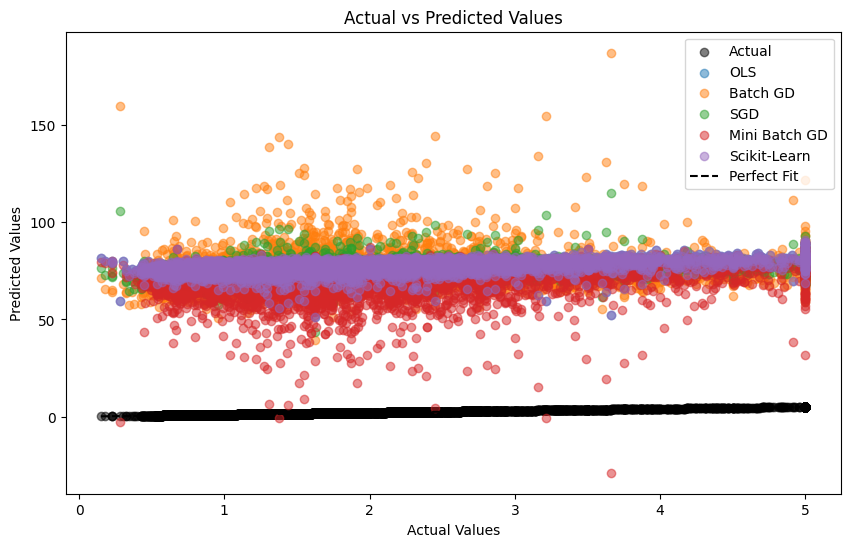

In [126]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    "OLS": ols,
    "Batch GD": batch_gd,
    "SGD": sgd,
    "Mini Batch GD": mini_batch,
    "Scikit-Learn": sk_model
}

plt.figure(figsize=(10,6))

# Actual values
plt.scatter(
    y_test,
    y_test,
    color="black",
    alpha=0.5,
    label="Actual"
)

# Predictions
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.scatter(
        y_test,
        y_pred,
        alpha=0.5,
        label=name
    )

# Perfect prediction line
min_val = min(y_test)
max_val = max(y_test)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Perfect Fit"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

The Actual vs Predicted plot shows how closely each model's predictions match the true target values.

### Observations:

- The diagonal dashed line represents perfect predictions where:

$ Actual = Predicted $

- Models with points closer to the perfect fit line produce more accurate predictions.

- **OLS and Scikit-Learn Linear Regression** show similar prediction behaviour because both use the Ordinary Least Squares optimization method.

- **Batch GD and SGD** predictions are close to OLS performance, indicating that gradient-based optimization successfully converged to a similar solution.

- **Mini-Batch GD** shows slightly more variation compared to other models due to gradient estimation using smaller subsets of data.

- The spread of points increases for some target values, indicating that the model has higher prediction error for certain samples.




---

# ii. Regression Lines Comparison



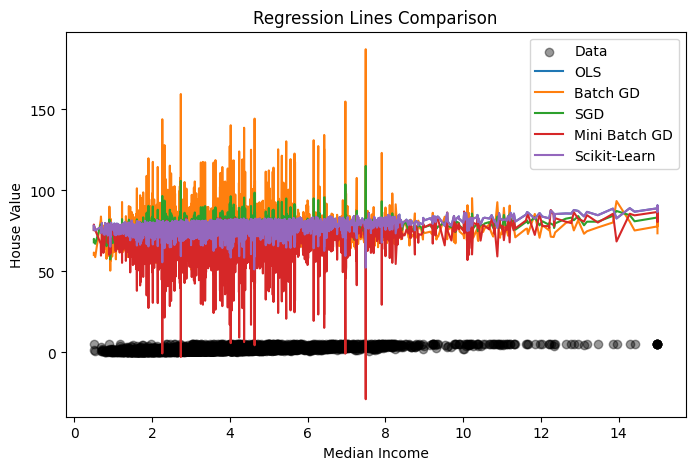

In [128]:
feature_index = 0

X_feature = X_test[:, feature_index]

plt.figure(figsize=(8,5))

plt.scatter(
    X_feature,
    y_test,
    color="black",
    alpha=0.4,
    label="Data"
)

for name, model in models.items():

    # Create sorted values for smooth line
    sorted_idx = np.argsort(X_feature)

    X_sorted = X_test[sorted_idx]

    y_pred = model.predict(X_sorted)

    plt.plot(
        X_feature[sorted_idx],
        y_pred,
        label=name
    )


plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Regression Lines Comparison")
plt.legend()
plt.show()

The regression line comparison shows the relationship between Median Income (selected feature) and predicted house values.

### Observations:

- The regression lines represent how each model predicts the target variable based on the selected feature.

- **OLS and Scikit-Learn** produce almost identical regression lines, confirming the correctness of the custom OLS implementation.

- **Batch GD and SGD** follow a similar trend to OLS, showing that iterative optimization methods learned comparable parameters.

- **Mini-Batch GD** shows more fluctuations because updates are performed using small batches, creating more variation in the learned parameters.

- The actual data points show that house value depends on multiple features, not only Median Income. Therefore, a single-feature visualization cannot fully represent the complete regression model.

---
# iii. Gradient Descent Convergence

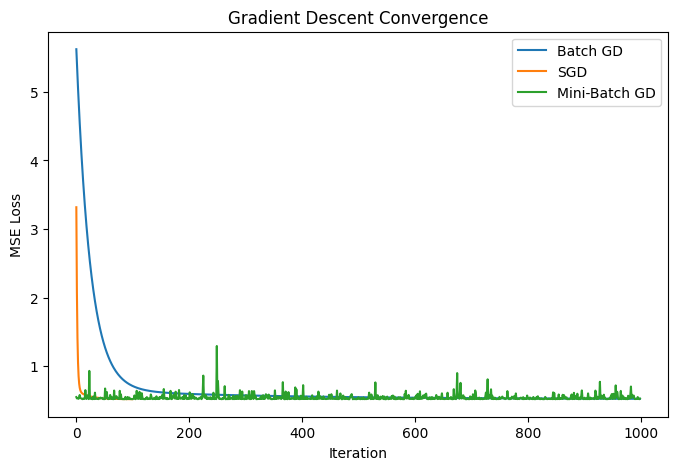

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    batch_gd.loss_history_,
    label="Batch GD"
)

plt.plot(
    sgd.loss_history_,
    label="SGD"
)

plt.plot(
    mini_batch.loss_history_,
    label="Mini-Batch GD"
)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")

plt.title("Gradient Descent Convergence")

plt.legend()
plt.show()

The convergence plot shows how the Mean Squared Error (MSE) changes during training iterations for gradient-based models.

### Observations:

- **Batch Gradient Descent** shows a smooth decrease in loss because gradients are calculated using the complete dataset at every iteration.

- **Stochastic Gradient Descent (SGD)** converges quickly but contains small fluctuations because each update is based on a single training sample.

- **Mini-Batch Gradient Descent** shows more variation compared to Batch GD because gradients are estimated from small batches instead of the complete dataset.

- All gradient-based models successfully reduce the loss, showing that the optimization algorithms are learning the regression parameters.

- The convergence behaviour depends on:
  - Learning rate
  - Number of iterations
  - Feature scaling
  - Batch size (for Mini-Batch GD)

# Overall Conclusion

The visualization confirms that the custom implementations of Linear Regression using OLS, Batch GD, SGD, and Mini-Batch GD produce results comparable to Scikit-Learn.

- OLS provides the exact closed-form solution.
- Batch GD provides stable convergence.
- SGD provides faster but noisier updates.
- Mini-Batch GD provides a balance between stability and computational efficiency.

The small differences between models are mainly due to the optimization approach and hyperparameter choices.